# Notebook 09 — Variables hidrológicas trimestrales del embalse

Este notebook construye la capa de **variables hidrológicas trimestrales** del modelo a partir de la base histórica de embalses publicada por el **MITECO**. Para Valmayor, se procesa la serie histórica de `agua_total` y `agua_actual`, se filtra por el embalse y se agrega a nivel de trimestre.

El objetivo ya no es trabajar con un target anual continuo, sino enriquecer el nuevo problema de **clasificación trimestral** con información hidrológica del embalse.

## Objetivo

- Descargar y leer la base histórica de embalses del MITECO.
- Filtrar únicamente el embalse de Valmayor.
- Limpiar fechas y variables numéricas.
- Construir variables hidrológicas agregadas por trimestre.
- Integrarlas con el target trimestral del notebook 07.
- Guardar el dataset hidrológico trimestral para el resto del pipeline.

## Preparación del entorno

Montaje de Google Drive e importación de las librerías base utilizadas en el resto del notebook.

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
from pathlib import Path
import os
import zipfile
import subprocess
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Rutas y configuración

Se definen las rutas de descarga del ZIP, la carpeta de extracción del `.mdb`, el target trimestral del notebook 07 y las rutas de salida de la tabla hidrológica trimestral y del dataset integrado.

In [17]:
BASE_DIR = Path("/content/drive/MyDrive/PIDS4jjj2")
DATA_DIR = BASE_DIR / "data" / "external"
OUT_DIR = BASE_DIR / "outputs" / "llm_activity"

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

ZIP_PATH = DATA_DIR / "BD-Embalses.zip"
MDB_DIR = DATA_DIR / "bd_embalses_mdb"
MDB_DIR.mkdir(parents=True, exist_ok=True)

RAW_CSV_PATH = DATA_DIR / "raw_embalses_historico.csv"
EMBALSE_QUARTER_PATH = DATA_DIR / "valmayor_embalse_by_quarter.csv"

TARGET_PATH = OUT_DIR / "valmayor_target_quarter_classification.parquet"
MODEL_HYDRO_PATH = OUT_DIR / "valmayor_target_hydro_quarter.parquet"
MODEL_HYDRO_CSV_PATH = OUT_DIR / "valmayor_target_hydro_quarter.csv"

print("DATA_DIR:", DATA_DIR)
print("OUT_DIR:", OUT_DIR)
print("TARGET_PATH:", TARGET_PATH)
print("EMBALSE_QUARTER_PATH:", EMBALSE_QUARTER_PATH)

DATA_DIR: /content/drive/MyDrive/PIDS4jjj2/data/external
OUT_DIR: /content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity
TARGET_PATH: /content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity/valmayor_target_quarter_classification.parquet
EMBALSE_QUARTER_PATH: /content/drive/MyDrive/PIDS4jjj2/data/external/valmayor_embalse_by_quarter.csv


## Descarga de la BD histórica del MITECO

Se descarga el ZIP oficial publicado por el MITECO con la histórica de embalses, se descomprime y se instala `mdbtools`, utilidad necesaria para leer el fichero MS Access `.mdb`.

In [18]:
!wget -O "/content/drive/MyDrive/PIDS4jjj2/data/external/BD-Embalses.zip" \
"https://www.miteco.gob.es/content/dam/miteco/es/agua/temas/evaluacion-de-los-recursos-hidricos/boletin-hidrologico/Historico-de-embalses/BD-Embalses.zip"

--2026-05-14 10:46:45--  https://www.miteco.gob.es/content/dam/miteco/es/agua/temas/evaluacion-de-los-recursos-hidricos/boletin-hidrologico/Historico-de-embalses/BD-Embalses.zip
Resolving www.miteco.gob.es (www.miteco.gob.es)... 150.171.110.65, 2620:1ec:29:1::39, 2620:1ec:48:1::39
Connecting to www.miteco.gob.es (www.miteco.gob.es)|150.171.110.65|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 11311721 (11M) [application/zip]
Saving to: ‘/content/drive/MyDrive/PIDS4jjj2/data/external/BD-Embalses.zip’

/content/drive/MyDr 100%[===================>]  10.79M  3.36MB/s    in 3.2s    

2026-05-14 10:46:50 (3.36 MB/s) - ‘/content/drive/MyDrive/PIDS4jjj2/data/external/BD-Embalses.zip’ saved [11311721/11311721]



In [19]:
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall(MDB_DIR)

print("Contenido extraído:")
for p in MDB_DIR.iterdir():
    print("-", p.name)

Contenido extraído:
- BD-Embalses.mdb


In [20]:
!apt-get -qq update
!apt-get -qq install -y mdbtools

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


In [21]:
mdb_files = list(MDB_DIR.glob("*.mdb")) + list(MDB_DIR.glob("*.MDB"))

print("MDB encontrados:")
for f in mdb_files:
    print("-", f)

MDB_PATH = mdb_files[0]
print("Usando:", MDB_PATH)

MDB encontrados:
- /content/drive/MyDrive/PIDS4jjj2/data/external/bd_embalses_mdb/BD-Embalses.mdb
Usando: /content/drive/MyDrive/PIDS4jjj2/data/external/bd_embalses_mdb/BD-Embalses.mdb


## Inspección de tablas del `.mdb`

Listado de las tablas disponibles en el `.mdb` y previsualización de sus primeras filas para localizar la tabla con el histórico de embalses.

In [22]:
!mdb-tables -1 "$MDB_PATH"

T_Datos Embalses 1988-2026


In [23]:
tables_raw = subprocess.check_output(f'mdb-tables -1 "{MDB_PATH}"', shell=True, text=True)
all_tables = [t.strip() for t in tables_raw.splitlines() if t.strip()]

for table in all_tables:
    print("=" * 100)
    print("TABLA:", table)
    try:
        cmd = f'mdb-export "{MDB_PATH}" "{table}" | head -n 5'
        out = subprocess.check_output(cmd, shell=True, text=True, stderr=subprocess.STDOUT)
        print(out)
    except Exception as e:
        print("No se pudo leer")

TABLA: T_Datos Embalses 1988-2026
AMBITO_NOMBRE,EMBALSE_NOMBRE,FECHA,AGUA_TOTAL,AGUA_ACTUAL,ELECTRICO_FLAG
"Miño - Sil","Albarellos","01/05/88 00:00:00","91,00","32,00",1
"Miño - Sil","Albarellos","01/12/88 00:00:00","91,00","44,00",1
"Miño - Sil","Albarellos","01/19/88 00:00:00","91,00","42,00",1
"Miño - Sil","Albarellos","01/26/88 00:00:00","91,00","43,00",1



## Exportación de la tabla a CSV

Se exporta la tabla histórica de embalses a un CSV intermedio para trabajarla con `pandas`.

In [24]:
TABLE_NAME = "T_Datos Embalses 1988-2026"
RAW_CSV_PATH = DATA_DIR / "raw_embalses_historico.csv"

!mdb-export "$MDB_PATH" "$TABLE_NAME" > "$RAW_CSV_PATH"

print("Guardado en:", RAW_CSV_PATH)

Guardado en: /content/drive/MyDrive/PIDS4jjj2/data/external/raw_embalses_historico.csv


## Carga del CSV exportado

Lectura del CSV con `pandas` y revisión rápida de su forma.

In [25]:
df_raw_embalse = pd.read_csv(RAW_CSV_PATH)

print(df_raw_embalse.shape)
df_raw_embalse.head()

(715237, 6)


,AMBITO_NOMBRE,EMBALSE_NOMBRE,FECHA,AGUA_TOTAL,AGUA_ACTUAL,ELECTRICO_FLAG
0,Miño - Sil,Albarellos,01/05/88 00:00:00,"91,00","32,00",1
1,Miño - Sil,Albarellos,01/12/88 00:00:00,"91,00","44,00",1
2,Miño - Sil,Albarellos,01/19/88 00:00:00,"91,00","42,00",1
3,Miño - Sil,Albarellos,01/26/88 00:00:00,"91,00","43,00",1
4,Miño - Sil,Albarellos,02/02/88 00:00:00,"91,00","65,00",1


### Inspección de columnas y tipos

In [26]:
print(df_raw_embalse.columns.tolist())
print()
print(df_raw_embalse.dtypes)

['AMBITO_NOMBRE', 'EMBALSE_NOMBRE', 'FECHA', 'AGUA_TOTAL', 'AGUA_ACTUAL', 'ELECTRICO_FLAG']

AMBITO_NOMBRE     object
EMBALSE_NOMBRE    object
FECHA             object
AGUA_TOTAL        object
AGUA_ACTUAL       object
ELECTRICO_FLAG     int64
dtype: object


## Limpieza inicial

Normalización de los nombres de columna (espacios y mayúsculas) para facilitar el filtrado y las transformaciones posteriores.

In [27]:
df_e = df_raw_embalse.copy()
df_e.columns = [c.strip().lower() for c in df_e.columns]

print(df_e.columns.tolist())

['ambito_nombre', 'embalse_nombre', 'fecha', 'agua_total', 'agua_actual', 'electrico_flag']


## Filtrado por el embalse de Valmayor

Se selecciona únicamente las filas cuyo `embalse_nombre` contiene `valmayor` (case-insensitive).

In [28]:
df_valmayor = df_e[
    df_e["embalse_nombre"].astype(str).str.contains("valmayor", case=False, na=False)
].copy()

print(df_valmayor.shape)
df_valmayor.head()

(2002, 6)


,ambito_nombre,embalse_nombre,fecha,agua_total,agua_actual,electrico_flag
219642,Tajo,Valmayor,01/05/88 00:00:00,"124,00","53,00",0
219643,Tajo,Valmayor,01/12/88 00:00:00,"124,00","57,00",0
219644,Tajo,Valmayor,01/19/88 00:00:00,"124,00","60,00",0
219645,Tajo,Valmayor,01/26/88 00:00:00,"124,00","68,00",0
219646,Tajo,Valmayor,02/02/88 00:00:00,"124,00","71,00",0


## Conversión de fechas y variables numéricas

Se convierte `fecha` a formato `datetime`, se transforman `agua_total` y `agua_actual` a variables numéricas y se generan las columnas temporales necesarias para trabajar a nivel trimestral.

In [29]:
df_valmayor = df_valmayor.copy()

# Fecha
df_valmayor["fecha"] = pd.to_datetime(
    df_valmayor["fecha"],
    format="%m/%d/%y %H:%M:%S",
    errors="coerce"
)

# Numéricas con coma decimal
df_valmayor["agua_total"] = (
    df_valmayor["agua_total"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df_valmayor["agua_actual"] = (
    df_valmayor["agua_actual"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df_valmayor["agua_total"] = pd.to_numeric(df_valmayor["agua_total"], errors="coerce")
df_valmayor["agua_actual"] = pd.to_numeric(df_valmayor["agua_actual"], errors="coerce")

# Componentes temporales
df_valmayor["year"] = df_valmayor["fecha"].dt.year
df_valmayor["quarter"] = df_valmayor["fecha"].dt.quarter
df_valmayor["year_quarter"] = (
    df_valmayor["year"].astype("Int64").astype(str) + "-Q" +
    df_valmayor["quarter"].astype("Int64").astype(str)
)

df_valmayor.head()

,ambito_nombre,embalse_nombre,fecha,agua_total,agua_actual,electrico_flag,year,quarter,year_quarter
219642,Tajo,Valmayor,1988-01-05,124.0,53.0,0,1988,1,1988-Q1
219643,Tajo,Valmayor,1988-01-12,124.0,57.0,0,1988,1,1988-Q1
219644,Tajo,Valmayor,1988-01-19,124.0,60.0,0,1988,1,1988-Q1
219645,Tajo,Valmayor,1988-01-26,124.0,68.0,0,1988,1,1988-Q1
219646,Tajo,Valmayor,1988-02-02,124.0,71.0,0,1988,1,1988-Q1


In [30]:
print("Filas totales:", len(df_valmayor))
print("Años disponibles:", df_valmayor["year"].min(), "-", df_valmayor["year"].max())
print("Trimestres disponibles:", df_valmayor["year_quarter"].nunique())
print()

print(df_valmayor[["agua_total", "agua_actual"]].describe())

Filas totales: 2002
Años disponibles: 1988 - 2026
Trimestres disponibles: 154

       agua_total  agua_actual
count      2002.0  2002.000000
mean        124.0    85.315185
std           0.0    22.405469
min         124.0    32.000000
25%         124.0    69.000000
50%         124.0    87.000000
75%         124.0   103.000000
max         124.0   123.000000


### Revisión de nulos

In [31]:
df_valmayor[["fecha", "agua_total", "agua_actual", "year"]].isna().sum()

,0
fecha,0
agua_total,0
agua_actual,0
year,0


### Ordenación por fecha

In [32]:
df_valmayor = df_valmayor.sort_values("fecha").reset_index(drop=True)

df_valmayor[["fecha", "year", "agua_total", "agua_actual"]].head()

,fecha,year,agua_total,agua_actual
0,1988-01-05,1988,124.0,53.0
1,1988-01-12,1988,124.0,57.0
2,1988-01-19,1988,124.0,60.0
3,1988-01-26,1988,124.0,68.0
4,1988-02-02,1988,124.0,71.0


### Cobertura por trimestre

Antes de la agregación final se revisa la cobertura temporal del embalse a nivel trimestral.

In [33]:
df_valmayor.groupby("year_quarter")[["agua_total", "agua_actual"]].agg(["count", "mean", "min", "max"]).head(12)

agua_total                      agua_actual                     \
                  count   mean    min    max       count        mean    min   
year_quarter                                                                  
1988-Q1              13  124.0  124.0  124.0          13   79.076923   53.0   
1988-Q2              13  124.0  124.0  124.0          13   94.461538   90.0   
1988-Q3              13  124.0  124.0  124.0          13   99.384615   92.0   
1988-Q4              13  124.0  124.0  124.0          13   87.384615   86.0   
1989-Q1              13  124.0  124.0  124.0          13   88.000000   84.0   
1989-Q2              13  124.0  124.0  124.0          13   85.615385   83.0   
1989-Q3              13  124.0  124.0  124.0          13   79.153846   71.0   
1989-Q4              13  124.0  124.0  124.0          13   78.769231   61.0   
1990-Q1              13  124.0  124.0  124.0          13  120.461538  117.0   
1990-Q2              13  124.0  124.0  124.0          13  111.846154  103.0   
1990-Q3              13  124.0  124.0  124.0          13   89.769231   80.0   
1990-Q4              13  124.0  124.0  124.0          13   70.538462   63.0   

                     
                max  
year_quarter         
1988-Q1        92.0  
1988-Q2        99.0  
1988-Q3       106.0  
1988-Q4        91.0  
1989-Q1        90.0  
1989-Q2        89.0  
1989-Q3        88.0  
1989-Q4       120.0  
1990-Q1       122.0  
1990-Q2       117.0  
1990-Q3       102.0  
1990-Q4        78.0

## Agregación trimestral

Para cada trimestre se calculan estadísticos básicos de `agua_total` y `agua_actual`, así como el número de observaciones hidrológicas disponibles. Las columnas se renombran con el sufijo `_quarter` para dejar explícito el nivel de agregación.

In [34]:
df_embalse_quarter = (
    df_valmayor
    .groupby(["year", "quarter", "year_quarter"], as_index=False)
    .agg(
        agua_total_mean_quarter=("agua_total", "mean"),
        agua_total_min_quarter=("agua_total", "min"),
        agua_total_max_quarter=("agua_total", "max"),
        agua_total_std_quarter=("agua_total", "std"),

        agua_actual_mean_quarter=("agua_actual", "mean"),
        agua_actual_min_quarter=("agua_actual", "min"),
        agua_actual_max_quarter=("agua_actual", "max"),
        agua_actual_std_quarter=("agua_actual", "std"),

        n_obs_embalse_quarter=("agua_actual", "count")
    )
    .sort_values(["year", "quarter"])
    .reset_index(drop=True)
)

df_embalse_quarter.head(12)

,year,quarter,year_quarter,agua_total_mean_quarter,agua_total_min_quarter,agua_total_max_quarter,agua_total_std_quarter,agua_actual_mean_quarter,agua_actual_min_quarter,agua_actual_max_quarter,agua_actual_std_quarter,n_obs_embalse_quarter
0,1988,1,1988-Q1,124.0,124.0,124.0,0.0,79.076923,53.0,92.0,15.019218,13
1,1988,2,1988-Q2,124.0,124.0,124.0,0.0,94.461538,90.0,99.0,3.688165,13
2,1988,3,1988-Q3,124.0,124.0,124.0,0.0,99.384615,92.0,106.0,4.426030,13
3,1988,4,1988-Q4,124.0,124.0,124.0,0.0,87.384615,86.0,91.0,1.502135,13
4,1989,1,1989-Q1,124.0,124.0,124.0,0.0,88.000000,84.0,90.0,1.732051,13
5,1989,2,1989-Q2,124.0,124.0,124.0,0.0,85.615385,83.0,89.0,1.980676,13
6,1989,3,1989-Q3,124.0,124.0,124.0,0.0,79.153846,71.0,88.0,5.756824,13
7,1989,4,1989-Q4,124.0,124.0,124.0,0.0,78.769231,61.0,120.0,20.269656,13
8,1990,1,1990-Q1,124.0,124.0,124.0,0.0,120.461538,117.0,122.0,1.613246,13
9,1990,2,1990-Q2,124.0,124.0,124.0,0.0,111.846154,103.0,117.0,4.524860,13


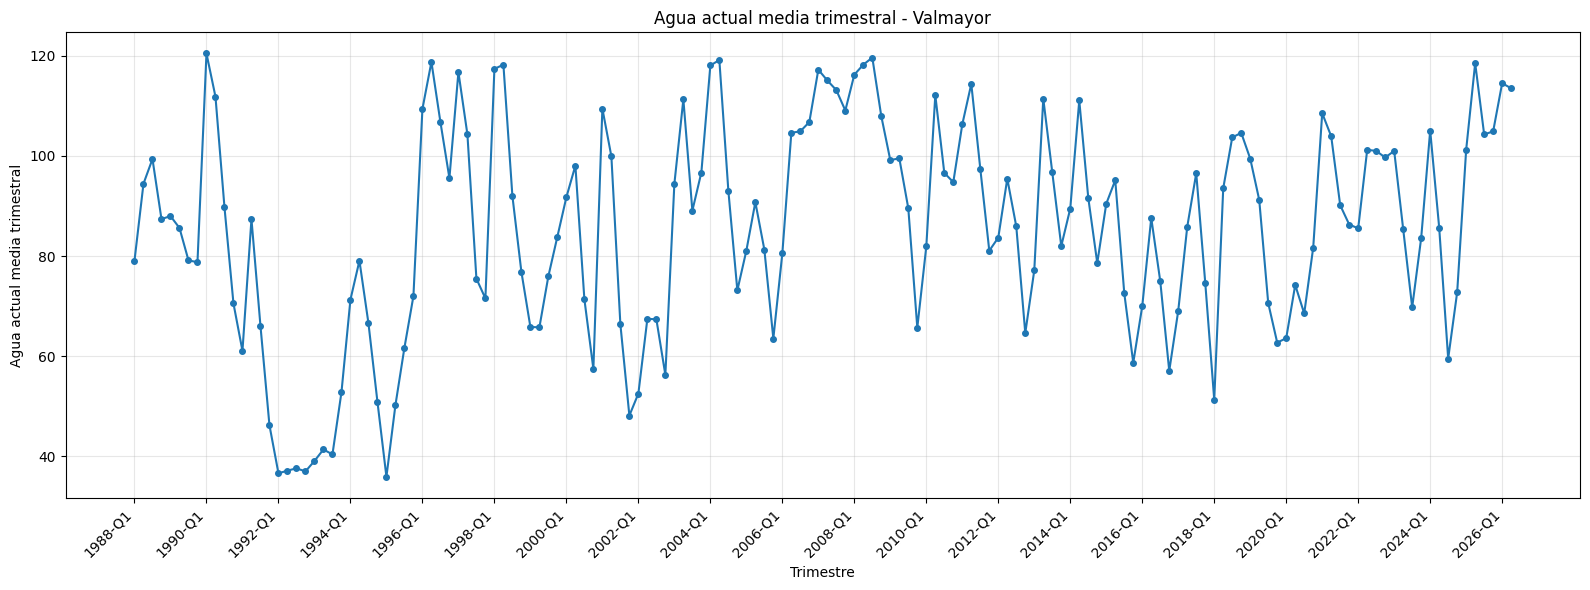

In [36]:
plt.figure(figsize=(16, 6))
x = range(len(df_embalse_quarter))

plt.plot(
    x,
    df_embalse_quarter["agua_actual_mean_quarter"],
    marker="o",
    linewidth=1.5,
    markersize=4
)

tick_positions = list(range(0, len(df_embalse_quarter), 8))
tick_labels = df_embalse_quarter["year_quarter"].iloc[tick_positions]

plt.xticks(tick_positions, tick_labels, rotation=45, ha="right")
plt.title("Agua actual media trimestral - Valmayor")
plt.xlabel("Trimestre")
plt.ylabel("Agua actual media trimestral")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Persistencia de la tabla hidrológica trimestral

Se guarda la tabla hidrológica trimestral, que servirá como una de las entradas del dataset final de modelado.

In [37]:
df_embalse_quarter.to_csv(EMBALSE_QUARTER_PATH, index=False, encoding="utf-8")
print("Guardado en:", EMBALSE_QUARTER_PATH)
print("Shape tabla trimestral:", df_embalse_quarter.shape)

Guardado en: /content/drive/MyDrive/PIDS4jjj2/data/external/valmayor_embalse_by_quarter.csv
Shape tabla trimestral: (154, 12)


## Integración con el target trimestral

Se cruza la tabla hidrológica trimestral con el dataset target del notebook 07 para dejar preparado el bloque hidrológico del modelado.

In [38]:
df_target = pd.read_parquet(TARGET_PATH)

print("Shape target:", df_target.shape)
df_target.head()

Shape target: (54, 11)


,year,year_quarter,n_videos,mean_activity_mentions,share_low,share_medium,share_high,share_certainty_high,captures_nonnull_mean,target_class,target_class_id
0,2009.0,2009-Q3,2,1.0,1.0,0.0,0.0,0.0,NaN,low,0
1,2009.0,2009-Q4,1,1.0,0.0,1.0,0.0,1.0,1.0,medium,1
2,2010.0,2010-Q1,1,1.0,1.0,0.0,0.0,0.0,NaN,low,0
3,2010.0,2010-Q2,2,1.0,0.0,1.0,0.0,0.5,1.0,medium,1
4,2011.0,2011-Q1,1,1.0,0.0,1.0,0.0,1.0,1.0,medium,1


In [39]:
df_model_hydro = (
    df_target
    .merge(
        df_embalse_quarter,
        on=["year", "year_quarter"],
        how="left"
    )
    .sort_values(["year", "year_quarter"])
    .reset_index(drop=True)
)

print("Shape tras merge:", df_model_hydro.shape)
df_model_hydro.head(12)

Shape tras merge: (54, 21)


,year,year_quarter,n_videos,mean_activity_mentions,share_low,share_medium,share_high,share_certainty_high,captures_nonnull_mean,target_class,...,quarter,agua_total_mean_quarter,agua_total_min_quarter,agua_total_max_quarter,agua_total_std_quarter,agua_actual_mean_quarter,agua_actual_min_quarter,agua_actual_max_quarter,agua_actual_std_quarter,n_obs_embalse_quarter
0,2009.0,2009-Q3,2,1.000000,1.000000,0.000000,0.0,0.000000,NaN,low,...,3,124.0,124.0,124.0,0.0,89.538462,75.0,103.0,9.252165,13
1,2009.0,2009-Q4,1,1.000000,0.000000,1.000000,0.0,1.000000,1.0,medium,...,4,124.0,124.0,124.0,0.0,65.692308,61.0,73.0,3.682948,13
2,2010.0,2010-Q1,1,1.000000,1.000000,0.000000,0.0,0.000000,NaN,low,...,1,124.0,124.0,124.0,0.0,81.923077,67.0,107.0,14.625671,13
3,2010.0,2010-Q2,2,1.000000,0.000000,1.000000,0.0,0.500000,1.0,medium,...,2,124.0,124.0,124.0,0.0,112.153846,109.0,115.0,2.511512,13
4,2011.0,2011-Q1,1,1.000000,0.000000,1.000000,0.0,1.000000,1.0,medium,...,1,124.0,124.0,124.0,0.0,106.307692,104.0,110.0,1.797434,13
5,2011.0,2011-Q3,3,1.000000,0.000000,1.000000,0.0,0.666667,1.0,medium,...,3,124.0,124.0,124.0,0.0,97.461538,87.0,110.0,7.774053,13
6,2011.0,2011-Q4,2,1.000000,0.500000,0.500000,0.0,0.500000,1.0,low,...,4,124.0,124.0,124.0,0.0,81.076923,77.0,86.0,2.431102,13
7,2012.0,2012-Q2,1,1.000000,1.000000,0.000000,0.0,0.000000,NaN,low,...,2,124.0,124.0,124.0,0.0,95.461538,91.0,98.0,2.295481,13
8,2012.0,2012-Q3,2,1.000000,1.000000,0.000000,0.0,0.000000,NaN,low,...,3,124.0,124.0,124.0,0.0,85.923077,73.0,95.0,8.460315,13
9,2012.0,2012-Q4,1,1.000000,0.000000,1.000000,0.0,0.000000,1.0,medium,...,4,124.0,124.0,124.0,0.0,64.615385,61.0,74.0,4.369181,13


### Resumen descriptivo por clase

Se analiza de forma preliminar cómo se comportan las variables hidrológicas según la clase objetivo trimestral.

In [41]:
summary_hydro_by_class = (
    df_model_hydro
    .groupby("target_class")
    .agg(
        n_trimestres=("year_quarter", "count"),
        n_videos_mean=("n_videos", "mean"),
        agua_actual_mean_quarter=("agua_actual_mean_quarter", "mean"),
        agua_actual_min_quarter=("agua_actual_min_quarter", "mean"),
        agua_actual_max_quarter=("agua_actual_max_quarter", "mean"),
        agua_total_mean_quarter=("agua_total_mean_quarter", "mean")
    )
    .round(3)
)

summary_hydro_by_class

,n_trimestres,n_videos_mean,agua_actual_mean_quarter,agua_actual_min_quarter,agua_actual_max_quarter,agua_total_mean_quarter
target_class,,,,,,
high,4,2.250,99.788,94.000,105.500,124.0
low,28,3.179,89.212,81.071,97.179,124.0
medium,22,2.318,88.678,82.273,95.227,124.0


## Guardado del dataset integrado con hidrología

Se persiste la versión del dataset que ya incorpora las variables hidrológicas trimestrales, lista para combinarse con el resto de bloques del pipeline.

In [42]:
df_model_hydro.to_parquet(MODEL_HYDRO_PATH, index=False)
df_model_hydro.to_csv(MODEL_HYDRO_CSV_PATH, index=False, encoding="utf-8")

print("Guardado parquet:", MODEL_HYDRO_PATH)
print("Guardado csv:", MODEL_HYDRO_CSV_PATH)

Guardado parquet: /content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity/valmayor_target_hydro_quarter.parquet
Guardado csv: /content/drive/MyDrive/PIDS4jjj2/outputs/llm_activity/valmayor_target_hydro_quarter.csv


## Conclusión

El notebook deja construida la tabla hidrológica trimestral del embalse de Valmayor y la integra con el target de clasificación trimestral definido en el notebook 07. De este modo, la hidrología queda adaptada al nuevo enfoque temporal del TFG y lista para combinarse con el resto de fuentes externas en los siguientes pasos del pipeline.